In [1]:
import pandas as pd
import numpy as np

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [2]:
X_train = pd.read_csv("shuffled_train_final_x.csv")
X_test = pd.read_csv("shuffled_test_final_x.csv")
X_val = pd.read_csv("shuffled_val_final_x.csv")

y_train = pd.read_csv("shuffled_train_final_y.csv")
y_test = pd.read_csv("shuffled_test_final_y.csv")
y_val = pd.read_csv("shuffled_val_final_y.csv")

In [3]:
X_train_pca = pd.read_csv("X_train_pca.csv")
print(X_train_pca.shape)

X_test_pca = pd.read_csv("X_test_pca.csv")
print(X_test_pca.shape)

X_val_pca = pd.read_csv("X_val_pca.csv")
print(X_val_pca.shape)

(7010, 27)
(1503, 27)
(1502, 27)


In [4]:
#THIS CELL is us experimenting with PCA
# create a SKLearn logistic regression classifier

ham10000_log_reg = LogisticRegression(penalty="l2", max_iter=5000)

In [5]:
#un-one-hot encode the labels
y_train_not_encoded = np.argmax(y_train, axis=1)
y_val_encoded = np.argmax(y_val, axis=1)

In [6]:
print(y_val_encoded.shape)

(1502,)


In [7]:

# fit the model to the training set
ham10000_log_reg.fit(X_train_pca, y_train_not_encoded)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [8]:
# get predictions on training and validation sets
y_train_pred = ham10000_log_reg.predict(X_train_pca)
y_val_pred  = ham10000_log_reg.predict(X_val_pca)

In [9]:
# get training accuracy and validation accuracy
train_acc = accuracy_score(y_train_not_encoded, y_train_pred)
val_acc  = accuracy_score(y_val_encoded,  y_val_pred)

print("Training accuracy:", train_acc)
print("Validation accuracy:", val_acc)

Training accuracy: 0.6834522111269615
Validation accuracy: 0.6018641810918774


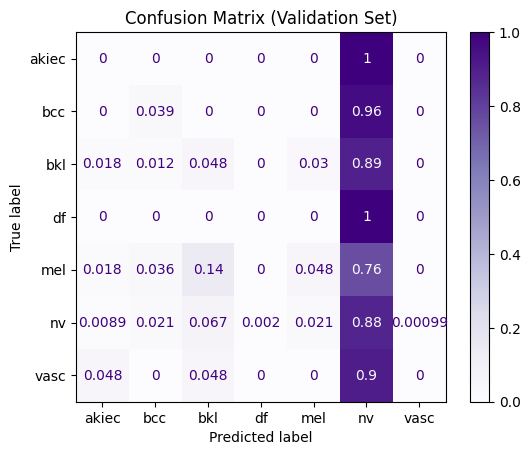

In [11]:
# make confusion matrix
cm = confusion_matrix(y_val_encoded, y_val_pred, normalize='true')
class_names = list(('akiec','bcc','bkl','df','mel','nv','vasc'))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Purples")
plt.title("Confusion Matrix (Validation Set)")
plt.show()
